In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#Loading the data
trends = pd.read_csv('ai_tools_comparison.csv')

#Inspecting the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


In [3]:
#'week' column to datetime format
trends['week'] = pd.to_datetime(trends['week'])

#'week' as the DataFrame index
trends.set_index('week', inplace=True)

print("Date range:", trends.index.min(), "to", trends.index.max())
print("Shape:", trends.shape)
trends.head()

Date range: 2023-08-27 00:00:00 to 2024-09-01 00:00:00
Shape: (54, 3)


,chatgpt,gemini,microsoft_copilot
week,,,
2023-08-27,56,3,1
2023-09-03,56,3,1
2023-09-10,63,3,1
2023-09-17,64,3,1
2023-09-24,66,3,1


In [4]:
#week-over-week percentage change
growth_rates = trends.pct_change().fillna(0).mul(100)

#standard deviation of growth rates
std_dev = growth_rates.std()
print("Standard deviations of weekly growth rates:")
print(std_dev.round(2))

#tool with the smallest std dev
most_consistent_tool = std_dev.idxmin()
print(f"\nMost consistent tool: {most_consistent_tool}")

Standard deviations of weekly growth rates:
chatgpt               8.97
gemini               36.03
microsoft_copilot    24.34
dtype: float64

Most consistent tool: chatgpt


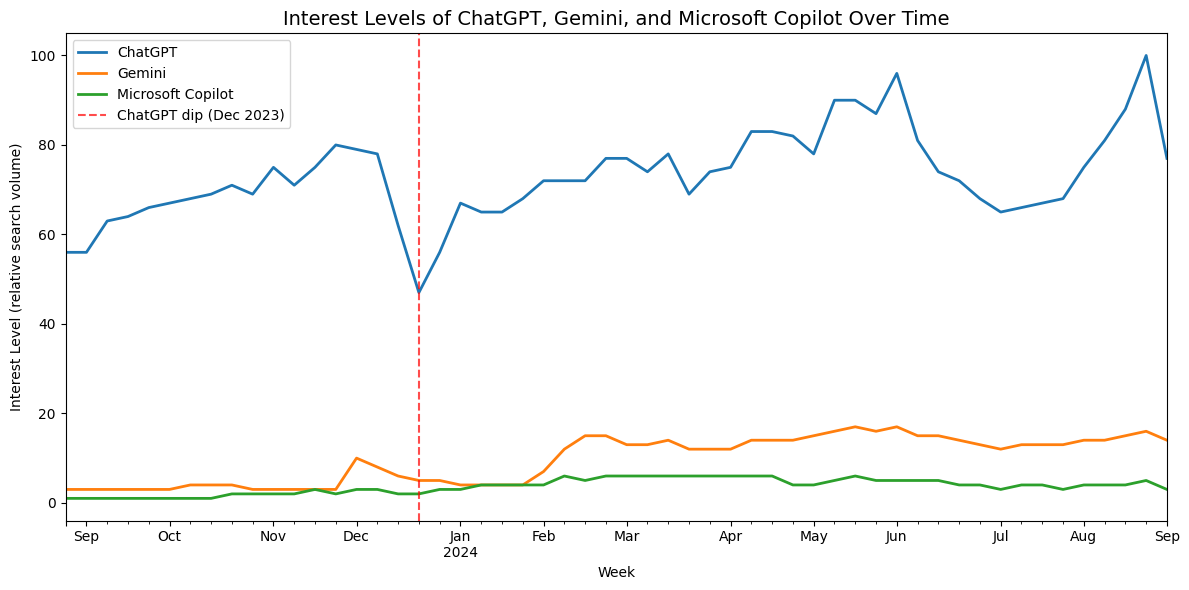

ChatGPT's largest dip: December 2023


In [5]:
#copy for plotting
interest_levels = trends.copy()
interest_levels.columns = ['ChatGPT', 'Gemini', 'Microsoft Copilot']

fig, ax = plt.subplots(figsize=(12, 6))
interest_levels.plot(ax=ax, linewidth=2)

# Marking the ChatGPT dip
ax.axvline(pd.Timestamp('2023-12-24'), color='red', linestyle='--', alpha=0.7, label='ChatGPT dip (Dec 2023)')
ax.set_title("Interest Levels of ChatGPT, Gemini, and Microsoft Copilot Over Time", fontsize=14)
ax.set_xlabel('Week')
ax.set_ylabel('Interest Level (relative search volume)')
ax.legend()
plt.tight_layout()
plt.show()

gpt_dip = "December 2023"
print(f"ChatGPT's largest dip: {gpt_dip}")

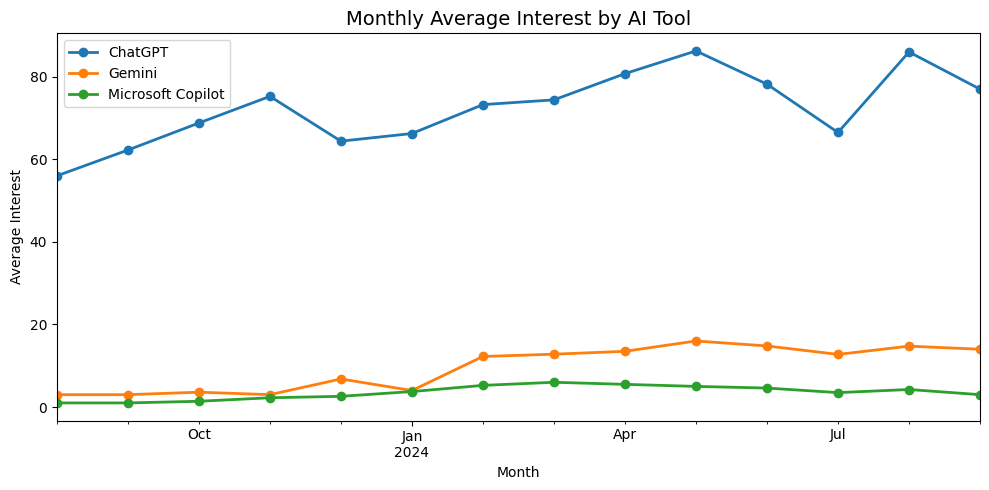

Month with highest average interest across all tools: May


In [6]:
monthly_data = trends.resample('ME').mean()
monthly_data.columns = ['ChatGPT', 'Gemini', 'Microsoft Copilot']

#Ploting monthly trends
fig, ax = plt.subplots(figsize=(10, 5))
monthly_data.plot(ax=ax, marker='o', linewidth=2)
ax.set_title("Monthly Average Interest by AI Tool", fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Interest')
plt.tight_layout()
plt.show()

# month with highest average interest
best_month = monthly_data.mean(axis=1).idxmax().strftime('%B')
print(f"Month with highest average interest across all tools: {best_month}")